In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Concatenate, Dense, Dropout, Flatten, Subtract, Multiply
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import re
import nltk
from nltk.corpus import stopwords
import os
import matplotlib.pyplot as plt

# Download NLTK data
nltk.download('stopwords')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
print("\n" + "="*70)
print("DOWNLOADING GLOVE EMBEDDINGS")
print("="*70)

# Paper uses 200d GloVe Twitter embeddings (27B tokens, 1.2M vocab)
GLOVE_URL = 'http://nlp.stanford.edu/data/glove.twitter.27B.zip'
GLOVE_FILE = '/content/drive/MyDrive/links/Quora duplicate questions/glove.twitter.27B.200d.txt'
EMBEDDING_DIM = 200  # As per paper

if not os.path.exists(GLOVE_FILE):
    print(f"\nDownloading GloVe embeddings from Stanford NLP...")
    print(f"This may take 5-10 minutes (file size: ~1.4GB)")

    try:
        # Download the zip file
        zip_file = 'glove.twitter.27B.zip'
        if not os.path.exists(zip_file):
            wget.download(GLOVE_URL, zip_file)

        print(f"\nExtracting {GLOVE_FILE}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extract(GLOVE_FILE)

        print(f"✓ GloVe embeddings downloaded successfully")
    except Exception as e:
        print(f"Error downloading GloVe: {e}")
        print("\nAlternative: Download manually from:")
        print("https://nlp.stanford.edu/projects/glove/")
        print(f"Then extract {GLOVE_FILE} to the current directory")
else:
    print(f"✓ GloVe embeddings already exist: {GLOVE_FILE}")


DOWNLOADING GLOVE EMBEDDINGS
✓ GloVe embeddings already exist: /content/drive/MyDrive/links/Quora duplicate questions/glove.twitter.27B.200d.txt


In [ ]:
print("\n" + "="*70)
print("LOADING QUORA DATASET")
print("="*70)

# Load the dataset (make sure the file name matches what you uploaded)
df = pd.read_csv('/content/drive/MyDrive/links/Quora duplicate questions/train.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")


LOADING QUORA DATASET
Dataset shape: (404290, 6)
Columns: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']

First few rows:
   id  qid1  qid2                                          question1  \
0   0     1     2  What is the step by step guide to invest in sh...   
1   1     3     4  What is the story of Kohinoor (Koh-i-Noor) Dia...   
2   2     5     6  How can I increase the speed of my internet co...   
3   3     7     8  Why am I mentally very lonely? How can I solve...   
4   4     9    10  Which one dissolve in water quikly sugar, salt...   

                                           question2  is_duplicate  
0  What is the step by step guide to invest in sh...             0  
1  What would happen if the Indian government sto...             0  
2  How can Internet speed be increased by hacking...             0  
3  Find the remainder when [math]23^{24}[/math] i...             0  
4            Which fish would survive in salt water?             0  

Missing val

In [ ]:
print("\n" + "="*70)
print("LOADING GLOVE EMBEDDINGS")
print("="*70)

def load_glove_embeddings(glove_file):
    """Load GloVe embeddings from file"""
    print(f"Loading GloVe from {glove_file}...")
    embeddings_index = {}

    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    print(f"✓ Loaded {len(embeddings_index):,} word vectors")
    return embeddings_index

# Load GloVe embeddings
glove_embeddings = load_glove_embeddings(GLOVE_FILE)


LOADING GLOVE EMBEDDINGS
Loading GloVe from /content/drive/MyDrive/links/Quora duplicate questions/glove.twitter.27B.200d.txt...
✓ Loaded 1,193,514 word vectors


In [ ]:
print("\n" + "="*70)
print("PREPROCESSING DATA")
print("="*70)

def preprocess_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = str(text).lower()

    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Apply preprocessing
df['question1'] = df['question1'].apply(preprocess_text)
df['question2'] = df['question2'].apply(preprocess_text)

# Remove rows based on paper's criteria:
# 1. Combined word count < 10
# 2. Either question > 59 words
df['q1_words'] = df['question1'].apply(lambda x: len(x.split()))
df['q2_words'] = df['question2'].apply(lambda x: len(x.split()))
df['total_words'] = df['q1_words'] + df['q2_words']

print(f"\nBefore filtering: {len(df)} pairs")
df = df[
    (df['total_words'] >= 10) &
    (df['q1_words'] <= 59) &
    (df['q2_words'] <= 59)
]
print(f"After filtering: {len(df)} pairs")
print(f"Duplicate percentage: {df['is_duplicate'].mean()*100:.2f}%")


PREPROCESSING DATA

Before filtering: 404290 pairs
After filtering: 393763 pairs
Duplicate percentage: 37.04%


In [ ]:
print("\n" + "="*70)
print("TOKENIZATION AND SEQUENCE PREPARATION")
print("="*70)

MAX_SEQUENCE_LENGTH = 59  # As per paper
MAX_VOCAB_SIZE = 50000

# Combine all questions for tokenization
all_questions = pd.concat([df['question1'], df['question2']]).unique()

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(all_questions)

vocab_size = min(len(tokenizer.word_index) + 1, MAX_VOCAB_SIZE)
print(f"\nVocabulary size: {vocab_size}")

# Convert questions to sequences
q1_sequences = tokenizer.texts_to_sequences(df['question1'])
q2_sequences = tokenizer.texts_to_sequences(df['question2'])

# Pad sequences
q1_padded = pad_sequences(q1_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
q2_padded = pad_sequences(q2_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# Get labels
labels = df['is_duplicate'].values

print(f"Q1 shape: {q1_padded.shape}")
print(f"Q2 shape: {q2_padded.shape}")
print(f"Labels shape: {labels.shape}")


TOKENIZATION AND SEQUENCE PREPARATION

Vocabulary size: 50000
Q1 shape: (393763, 59)
Q2 shape: (393763, 59)
Labels shape: (393763,)


In [ ]:
print("\n" + "="*70)
print("CREATING EMBEDDING MATRIX FROM GLOVE")
print("="*70)

def create_embedding_matrix(word_index, embeddings_index, embedding_dim, max_vocab_size):
    embedding_matrix = np.random.normal(
        loc=0.0, scale=0.05,
        size=(min(len(word_index) + 1, max_vocab_size), embedding_dim)
    )

    found_words = 0
    for word, i in word_index.items():
        if i >= max_vocab_size:
            continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            found_words += 1

    print(f"Found {found_words}/{min(len(word_index), max_vocab_size)} words in GloVe")
    print(f"Coverage: {found_words/min(len(word_index), max_vocab_size)*100:.2f}%")

    return embedding_matrix

# Create the embedding matrix
embedding_matrix = create_embedding_matrix(
    tokenizer.word_index,
    glove_embeddings,
    EMBEDDING_DIM,
    MAX_VOCAB_SIZE
)

print(f"Embedding matrix shape: {embedding_matrix.shape}")


CREATING EMBEDDING MATRIX FROM GLOVE
Found 38311/50000 words in GloVe
Coverage: 76.62%
Embedding matrix shape: (50000, 200)


In [ ]:
print("\n" + "="*70)
print("SPLITTING DATA")
print("="*70)

X1_train, X1_test, X2_train, X2_test, y_train, y_test = train_test_split(
    q1_padded, q2_padded, labels,
    test_size=0.10,
    random_state=42,
    stratify=labels
)

# Validation split (4% of training → ~3.6% overall)
X1_train, X1_val, X2_train, X2_val, y_train, y_val = train_test_split(
    X1_train, X2_train, y_train,
    test_size=0.04,
    random_state=42,
    stratify=y_train
)

print(f"\nTraining set: {len(X1_train)} pairs")
print(f"Validation set: {len(X1_val)} pairs")
print(f"Test set: {len(X1_test)} pairs")


SPLITTING DATA

Training set: 340210 pairs
Validation set: 14176 pairs
Test set: 39377 pairs


In [ ]:
print("\n" + "="*70)
print("BUILDING MODEL WITH GLOVE EMBEDDINGS")
print("="*70)

def create_lstm_model_with_glove(embedding_matrix, max_length, lstm_units=5):
    vocab_size, embedding_dim = embedding_matrix.shape

    # Shared embedding layer with GloVe weights (frozen initially)
    embedding_layer = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False,
        name='glove_embedding'
    )

    # Shared Bidirectional LSTM
    lstm_layer = Bidirectional(
        LSTM(lstm_units, return_sequences=True),
        name='bidirectional_lstm'
    )

    # Inputs
    input_q1 = Input(shape=(max_length,), name='question1')
    input_q2 = Input(shape=(max_length,), name='question2')

    # Siamese branches
    embedded_q1 = embedding_layer(input_q1)
    embedded_q2 = embedding_layer(input_q2)

    lstm_q1 = lstm_layer(embedded_q1)
    lstm_q2 = lstm_layer(embedded_q2)

    # Flatten to get feature vectors
    flatten_q1 = Flatten()(lstm_q1)
    flatten_q2 = Flatten()(lstm_q2)

    # Interaction features (as per Bowman et al.)
    subtract = Subtract()([flatten_q1, flatten_q2])
    multiply = Multiply()([flatten_q1, flatten_q2])

    concatenated = Concatenate()([flatten_q1, flatten_q2, subtract, multiply])

    # MLP hidden layer size = floor(sqrt(input_dim))
    concat_size = concatenated.shape[-1]
    hidden_size = int(np.sqrt(concat_size))

    hidden = Dense(hidden_size, activation='relu', name='hidden_layer')(concatenated)
    hidden = Dropout(0.3)(hidden)

    output = Dense(2, activation='softmax', name='output_layer')(hidden)

    model = Model(inputs=[input_q1, input_q2], outputs=output)
    return model

# Create model
model = create_lstm_model_with_glove(
    embedding_matrix=embedding_matrix,
    max_length=MAX_SEQUENCE_LENGTH,
    lstm_units=5
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n" + "="*70)
print("MODEL ARCHITECTURE WITH GLOVE EMBEDDINGS")
print("="*70)
model.summary()


BUILDING MODEL WITH GLOVE EMBEDDINGS


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



MODEL ARCHITECTURE WITH GLOVE EMBEDDINGS


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ question1           │ (None, 59)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ question2           │ (None, 59)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ glove_embedding     │ (None, 59, 200)   │ 10,000,000 │ question1[0][0],  │
│ (Embedding)         │                   │            │ question2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_lstm  │ (None, 59, 10)    │      8,240 │ glove_embedding[… │
│ (Bidirectional)     │                   │            │ glove_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 590)       │          0 │ bidirectional_ls… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 590)       │          0 │ bidirectional_ls… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 590)       │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 590)       │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2360)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ subtract[0][0],   │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_layer        │ (None, 48)        │    113,328 │ concatenate[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48)        │          0 │ hidden_layer[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 2)         │         98 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,121,666 (38.61 MB)

 Trainable params: 121,666 (475.26 KB)

 Non-trainable params: 10,000,000 (38.15 MB)

In [ ]:
print("\n" + "="*70)
print("TRAINING MODEL")
print("="*70)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

history = model.fit(
    [X1_train, X2_train],
    y_train,
    batch_size=64,
    epochs=20,
    validation_data=([X1_val, X2_val], y_val),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)


TRAINING MODEL
Epoch 1/20
5313/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7139 - loss: 0.5384
Epoch 1: val_accuracy improved from -inf to 0.77737, saving model to best_lstm_model.h5


5316/5316 ━━━━━━━━━━━━━━━━━━━━ 107s 19ms/step - accuracy: 0.7139 - loss: 0.5384 - val_accuracy: 0.7774 - val_loss: 0.4501
Epoch 2/20
5314/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7775 - loss: 0.4510
Epoch 2: val_accuracy improved from 0.77737 to 0.78562, saving model to best_lstm_model.h5


5316/5316 ━━━━━━━━━━━━━━━━━━━━ 82s 15ms/step - accuracy: 0.7775 - loss: 0.4510 - val_accuracy: 0.7856 - val_loss: 0.4349
Epoch 3/20
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7915 - loss: 0.4295
Epoch 3: val_accuracy improved from 0.78562 to 0.79106, saving model to best_lstm_model.h5


5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.7915 - loss: 0.4295 - val_accuracy: 0.7911 - val_loss: 0.4266
Epoch 4/20
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7989 - loss: 0.4169
Epoch 4: val_accuracy improved from 0.79106 to 0.79726, saving model to best_lstm_model.h5


5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.7989 - loss: 0.4169 - val_accuracy: 0.7973 - val_loss: 0.4212
Epoch 5/20
5315/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8045 - loss: 0.4082
Epoch 5: val_accuracy improved from 0.79726 to 0.79924, saving model to best_lstm_model.h5


...

5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.8119 - loss: 0.3953 - val_accuracy: 0.8059 - val_loss: 0.4092
Epoch 9/20
5315/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8171 - loss: 0.3876
Epoch 9: val_accuracy improved from 0.80587 to 0.80777, saving model to best_lstm_model.h5


5316/5316 ━━━━━━━━━━━━━━━━━━━━ 81s 15ms/step - accuracy: 0.8171 - loss: 0.3876 - val_accuracy: 0.8078 - val_loss: 0.4078
Epoch 10/20
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8197 - loss: 0.3832
Epoch 10: val_accuracy improved from 0.80777 to 0.80841, saving model to best_lstm_model.h5


5316/5316 ━━━━━━━━━━━━━━━━━━━━ 82s 15ms/step - accuracy: 0.8197 - loss: 0.3832 - val_accuracy: 0.8084 - val_loss: 0.4070
Epoch 11/20
5313/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8210 - loss: 0.3807
Epoch 11: val_accuracy did not improve from 0.80841
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.8210 - loss: 0.3807 - val_accuracy: 0.8074 - val_loss: 0.4070
Epoch 12/20
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8208 - loss: 0.3791
Epoch 12: val_accuracy improved from 0.80841 to 0.81081, saving model to best_lstm_model.h5


5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.8208 - loss: 0.3791 - val_accuracy: 0.8108 - val_loss: 0.4048
Epoch 13/20
5313/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8230 - loss: 0.3758
Epoch 13: val_accuracy did not improve from 0.81081
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 81s 15ms/step - accuracy: 0.8230 - loss: 0.3758 - val_accuracy: 0.8090 - val_loss: 0.4062
Epoch 14/20
5313/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8247 - loss: 0.3736
Epoch 14: val_accuracy did not improve from 0.81081
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.8247 - loss: 0.3736 - val_accuracy: 0.8097 - val_loss: 0.4045
Epoch 15/20
5314/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8261 - loss: 0.3721
Epoch 15: val_accuracy improved from 0.81081 to 0.81426, saving model to best_lstm_model.h5


5316/5316 ━━━━━━━━━━━━━━━━━━━━ 81s 15ms/step - accuracy: 0.8261 - loss: 0.3721 - val_accuracy: 0.8143 - val_loss: 0.4032
Epoch 16/20
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8270 - loss: 0.3700
Epoch 16: val_accuracy did not improve from 0.81426
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.8270 - loss: 0.3700 - val_accuracy: 0.8131 - val_loss: 0.4071
Epoch 17/20
5315/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8278 - loss: 0.3684
Epoch 17: val_accuracy did not improve from 0.81426
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.8278 - loss: 0.3684 - val_accuracy: 0.8114 - val_loss: 0.4086
Epoch 18/20
5315/5316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8306 - loss: 0.3653
Epoch 18: val_accuracy did not improve from 0.81426
5316/5316 ━━━━━━━━━━━━━━━━━━━━ 80s 15ms/step - accuracy: 0.8306 - loss: 0.3653 - val_accuracy: 0.8097 - val_loss: 0.4057


In [ ]:
print("\n" + "="*70)
print("EVALUATING MODEL")
print("="*70)

y_pred_probs = model.predict([X1_test, X2_test])
y_pred = np.argmax(y_pred_probs, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Expected from paper: ~0.8107")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Duplicate', 'Duplicate']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


EVALUATING MODEL
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step

TEST SET EVALUATION
Test Accuracy: 0.8035
Expected from paper: ~0.8107

Classification Report:
               precision    recall  f1-score   support

Non-Duplicate       0.85      0.84      0.84     24790
    Duplicate       0.73      0.74      0.74     14587

     accuracy                           0.80     39377
    macro avg       0.79      0.79      0.79     39377
 weighted avg       0.80      0.80      0.80     39377


Confusion Matrix:
[[20856  3934]
 [ 3802 10785]]


In [ ]:
print("\n" + "="*70)
print("SAVING MODEL AND ARTIFACTS")
print("="*70)

model.save('lstm_duplicate_detector.h5')
print("✓ Model saved as 'lstm_duplicate_detector.h5'")

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ Tokenizer saved as 'tokenizer.pkl'")

config = {
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
    'vocab_size': vocab_size,
    'embedding_dim': EMBEDDING_DIM,
    'lstm_units': 5,
    'glove_file': GLOVE_FILE,
    'embedding_trainable': False
}
with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("✓ Model config saved")

with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✓ Training history saved")

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)


SAVING MODEL AND ARTIFACTS
✓ Model saved as 'lstm_duplicate_detector.h5'
✓ Tokenizer saved as 'tokenizer.pkl'
✓ Model config saved
✓ Training history saved

TRAINING COMPLETE!



TRAINING VISUALIZATION


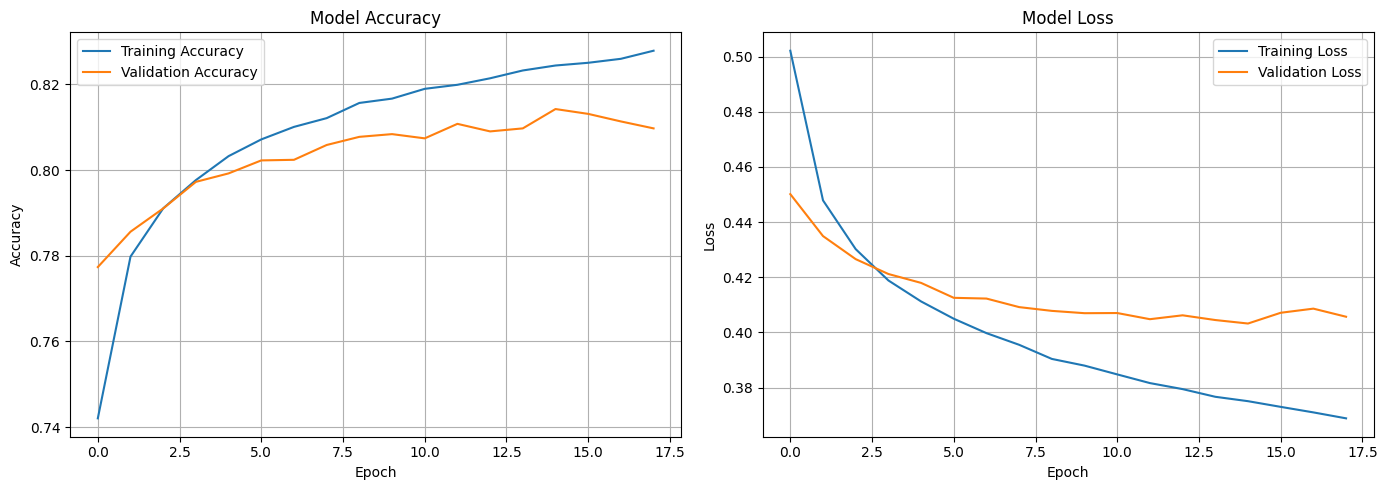

✓ Training plots saved as 'training_history.png'


In [ ]:
print("\n" + "="*70)
print("TRAINING VISUALIZATION")
print("="*70)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Training plots saved as 'training_history.png'")

In [ ]:
def predict_duplicate(question1, question2, model, tokenizer, max_length):
    q1 = preprocess_text(question1)
    q2 = preprocess_text(question2)

    q1_seq = tokenizer.texts_to_sequences([q1])
    q2_seq = tokenizer.texts_to_sequences([q2])

    q1_pad = pad_sequences(q1_seq, maxlen=max_length, padding='post')
    q2_pad = pad_sequences(q2_seq, maxlen=max_length, padding='post')

    pred = model.predict([q1_pad, q2_pad], verbose=0)
    confidence = pred[0][1]

    return confidence

print("\n" + "="*70)
print("SAMPLE PREDICTIONS")
print("="*70)

test_pairs = [
    ("How do I learn Python?", "What is the best way to learn Python?"),
    ("What is machine learning?", "How do I bake a cake?"),
    ("What's the capital of France?", "What is the capital city of France?"),
    ("How can I lose weight fast?", "What are quick ways to reduce body weight?")
]

for q1, q2 in test_pairs:
    conf = predict_duplicate(q1, q2, model, tokenizer, MAX_SEQUENCE_LENGTH)
    result = "DUPLICATE" if conf > 0.5 else "NOT DUPLICATE"
    print(f"\nQ1: {q1}")
    print(f"Q2: {q2}")
    print(f"Prediction: {result} (confidence: {conf:.4f})")

print("\n" + "="*70)
print("GLOVE-ENHANCED LSTM MODEL READY!")
print("="*70)


SAMPLE PREDICTIONS

Q1: How do I learn Python?
Q2: What is the best way to learn Python?
Prediction: DUPLICATE (confidence: 0.8097)

Q1: What is machine learning?
Q2: How do I bake a cake?
Prediction: NOT DUPLICATE (confidence: 0.0142)

Q1: What's the capital of France?
Q2: What is the capital city of France?
Prediction: DUPLICATE (confidence: 0.5776)

Q1: How can I lose weight fast?
Q2: What are quick ways to reduce body weight?
Prediction: DUPLICATE (confidence: 0.9050)

GLOVE-ENHANCED LSTM MODEL READY!
